<a href="https://colab.research.google.com/github/abini-nk/telco-customer-churn/blob/main/telco_customer_churn_pred_pynp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Telco Customer Churn Prediction**

###Project Overview
This project focuses on predicting customer churn for a Telecommunications company using Machine Learning models. By identifying churn-risk customers early, the retention team can take proactive business decisions to reduce customer loss.

- **Dataset:** Telco Customer Churn Dataset (IBM)
- **Target Variable:** `Churn` (Yes / No)
- **Workflow:** Data Cleaning ➔ Encoding ➔ Class Imbalance Handling (SMOTE) ➔ Model Training ➔ Feature Importance Analysis

## 1. Import Libraries & Load Data



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Load Data via Direct URL
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Preprocessing & Cleaning

In [ ]:
# Convert 'TotalCharges' column to numerical format (invalid values will become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check total missing values in 'TotalCharges'
print("Missing TotalCharges count:", df['TotalCharges'].isnull().sum())

# Impute missing values using median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop 'customerID' column as it is not relevant for predictive modeling
df.drop(columns=['customerID'], errors='ignore', inplace=True)

Missing TotalCharges count: 11


## 3. Data Encoding, Model Training & Evaluation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score


url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df.drop(columns=['customerID'], errors='ignore', inplace=True)


df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df_encoded = pd.get_dummies(df, drop_first=True)

# 4. Train-Test Split
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Handling Class Imbalance using (SMOTE)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# 7. Model Training & Evaluation
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    print(f"================ {name} ================")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")

================ Logistic Regression ================
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC Score: 0.8403

================ Random Forest ================
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1035
           1       0.57      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409

ROC-AUC Score: 0.8236

================ XGBoost ================
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1035
           1       0.57      0.59      0.58    

## 4. Feature Importance Analysis & Visualization

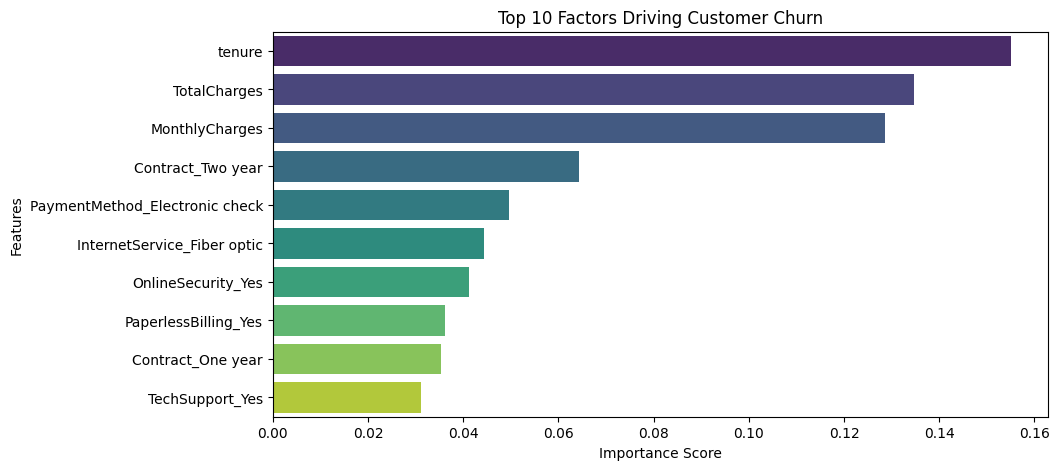

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure the models dictionary and X are available (defined in the training cell)
try:
    # Extract feature importances from Random Forest model
    rf_model = models['Random Forest']
    importances = rf_model.feature_importances_
    feature_names = X.columns

    # Extract Top 10 important features
    feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

    # Visualize Top 10 Features
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Importance', y='Feature', data=feat_df, hue='Feature', palette='viridis', legend=False)
    plt.title('Top 10 Factors Driving Customer Churn')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.show()
except NameError as e:
    print(f"Error: {e}\n")
    print("Please run the model training cell (cell _26Z6T31VvTk) first to define the 'models' and 'X' variables.")

## 5. XGBoost vs Random Forest Feature Comparison

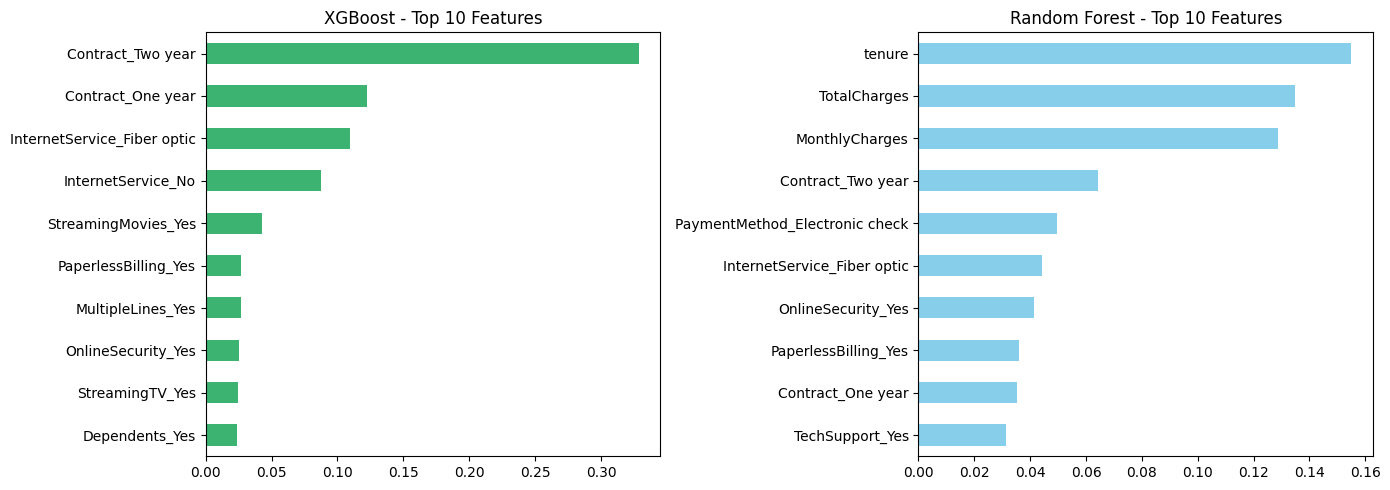

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. XGBoost Top 10 Features
xgb_imp = pd.Series(models['XGBoost'].feature_importances_, index=X.columns).nlargest(10)

# 2. Random Forest Top 10 Features
rf_imp = pd.Series(models['Random Forest'].feature_importances_, index=X.columns).nlargest(10)

# Plotting Side-by-Side
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
xgb_imp.sort_values().plot(kind='barh', color='mediumseagreen')
plt.title('XGBoost - Top 10 Features')

plt.subplot(1, 2, 2)
rf_imp.sort_values().plot(kind='barh', color='skyblue')
plt.title('Random Forest - Top 10 Features')

plt.tight_layout()
plt.show()

## 6. Conclusion & Key Insights

### Model Performance Summary:
- **Logistic Regression:** Achieved the highest recall (80%) for predicting customer churn, making it the most effective model for identifying churn-risk customers early.
- **Random Forest & XGBoost:** Delivered higher overall accuracy (77% - 78%) and overall stability, suitable for balanced decision-making.

###  Key Drivers of Customer Churn:
Based on feature importance visualizations, the primary drivers of churn include:
1. **Tenure:** Newer customers with shorter tenures show a significantly higher likelihood of churning.
2. **Contract Type:** Customers on Month-to-month contracts churn at a much higher rate compared to those on long-term contracts.
3. **Internet Service:** Customers subscribed to Fiber optic internet exhibit higher churn rates.
4. **Total & Monthly Charges:** High monthly charges and electronic check payment methods strongly influence customer departure.
---
###  Business Recommendations:
- **Onboarding Focus:** Implement proactive retention strategies for new customers during their initial months.
- **Contract Incentives:** Offer discounts or value-added perks to convert Month-to-month subscribers into 1-year or 2-year plans.
- **Service Quality:** Investigate Fiber optic service feedback to address potential service quality or pricing dissatisfaction.